# Configuration

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.linalg import fractional_matrix_power

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

BASE_PATH = '...'
CSV_PATH  = os.path.join(BASE_PATH, 'Combined.csv')
OUT_PATH  = BASE_PATH

df = pd.read_csv(CSV_PATH, low_memory=False)
df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [17]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum().sum())
print(df.describe())

(1215890, 52)
Unnamed: 0       int64
Seq              int64
Dur            float64
RunTime        float64
Mean           float64
Sum            float64
Min            float64
Max            float64
Proto           object
sTos           float64
dTos           float64
sDSb            object
dDSb            object
sTtl           float64
dTtl           float64
sHops          float64
dHops          float64
Cause           object
TotPkts          int64
SrcPkts          int64
DstPkts          int64
TotBytes         int64
SrcBytes         int64
DstBytes         int64
Offset           int64
sMeanPktSz     float64
dMeanPktSz     float64
Load           float64
SrcLoad        float64
DstLoad        float64
Loss             int64
SrcLoss          int64
DstLoss          int64
pLoss          float64
SrcGap         float64
DstGap         float64
Rate           float64
SrcRate        float64
DstRate        float64
State           object
SrcWin         float64
DstWin         float64
sVid           float

In [18]:
print(df['Label'].value_counts())

Label
Malicious    738153
Benign       477737
Name: count, dtype: int64


# Data Preprocessing

In [19]:
features = [col for col in df.columns if col not in ['Label']]
df_features = df[features]
print(df_features.columns.tolist())
print(df_features.shape)

['Unnamed: 0', 'Seq', 'Dur', 'RunTime', 'Mean', 'Sum', 'Min', 'Max', 'Proto', 'sTos', 'dTos', 'sDSb', 'dDSb', 'sTtl', 'dTtl', 'sHops', 'dHops', 'Cause', 'TotPkts', 'SrcPkts', 'DstPkts', 'TotBytes', 'SrcBytes', 'DstBytes', 'Offset', 'sMeanPktSz', 'dMeanPktSz', 'Load', 'SrcLoad', 'DstLoad', 'Loss', 'SrcLoss', 'DstLoss', 'pLoss', 'SrcGap', 'DstGap', 'Rate', 'SrcRate', 'DstRate', 'State', 'SrcWin', 'DstWin', 'sVid', 'dVid', 'SrcTCPBase', 'DstTCPBase', 'TcpRtt', 'SynAck', 'AckDat', 'Attack Type', 'Attack Tool']
(1215890, 51)


In [20]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [21]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct.round(2)
})

missing_cols = missing_df[missing_df['Missing Count'] > 0]

if missing_cols.empty:
    print("No missing values found.")
else:
    print(f"Missing values found in {len(missing_cols)} column(s):\n")
    print(missing_cols.to_string())

print(f"Total rows       : {len(df)}")
print(f"Total columns    : {df.shape[1]}")
print(f"Total missing    : {df.isnull().sum().sum()}")
print(f"Affected columns : {len(missing_cols)}")

Missing values found in 16 column(s):

            Missing Count  Missing (%)
sTos                  214         0.02
dTos               943067        77.56
sDSb                  214         0.02
dDSb               943067        77.56
sTtl                  214         0.02
dTtl               943067        77.56
sHops                 214         0.02
dHops              943067        77.56
SrcGap             937219        77.08
DstGap             937219        77.08
SrcWin             973470        80.06
DstWin            1038812        85.44
sVid              1101319        90.58
dVid              1213881        99.83
SrcTCPBase         937219        77.08
DstTCPBase         985843        81.08
Total rows       : 1215890
Total columns    : 51
Total missing    : 11898106
Affected columns : 16


In [ ]:

drop_cols = ['Proto', 'sDSb', 'dDSb', 'Cause', 'State', 'Attack Type', 'Attack Tool']
drop_cols = [c for c in drop_cols if c in df.columns]
df = df.drop(columns=drop_cols)
label   = df['Label']
df_feat = df.drop(columns=['Label'])
df_temp = df_feat.fillna(0)

zero_var_cols = df_temp.columns[df_temp.var() == 0].tolist()
print(f'Kolom variance=0 (akan di-drop): {zero_var_cols}')
df_feat = df_feat.drop(columns=zero_var_cols)
for col in df_feat.columns:
    if df_feat[col].isna().any():
        df_feat[col] = df_feat[col].fillna(df_feat[col].median())
df = pd.concat([df_feat, label], axis=1)
df.reset_index(drop=True, inplace=True)
df_numeric = df_feat
numeric_valid_cols = [col for col in df_numeric.columns if df_numeric[col].std() > 0]
print(f'\nTotal fitur numerik valid: {len(numeric_valid_cols)}')

Kolom variance=0 (akan di-drop): []

Total fitur numerik valid: 41


In [23]:
import itertools

features = numeric_valid_cols
combinations = list(itertools.combinations(features, 2))
set_X = combinations[:len(combinations)//2]
set_Y = combinations[len(combinations)//2:]

print(f"Set X - ({len(set_X)} combination):")
for i, comb in enumerate(set_X, 1):
    print(f"  {i:2d}. {comb}")

print(f"\nSet Y - ({len(set_Y)} combination):")
for i, comb in enumerate(set_Y, 1):
    print(f"  {i:2d}. {comb}")

Set X - (410 combination):
   1. ('Seq', 'Dur')
   2. ('Seq', 'RunTime')
   3. ('Seq', 'Mean')
   4. ('Seq', 'Sum')
   5. ('Seq', 'Min')
   6. ('Seq', 'Max')
   7. ('Seq', 'sTos')
   8. ('Seq', 'dTos')
   9. ('Seq', 'sTtl')
  10. ('Seq', 'dTtl')
  11. ('Seq', 'sHops')
  12. ('Seq', 'dHops')
  13. ('Seq', 'TotPkts')
  14. ('Seq', 'SrcPkts')
  15. ('Seq', 'DstPkts')
  16. ('Seq', 'TotBytes')
  17. ('Seq', 'SrcBytes')
  18. ('Seq', 'DstBytes')
  19. ('Seq', 'Offset')
  20. ('Seq', 'sMeanPktSz')
  21. ('Seq', 'dMeanPktSz')
  22. ('Seq', 'Load')
  23. ('Seq', 'SrcLoad')
  24. ('Seq', 'DstLoad')
  25. ('Seq', 'Loss')
  26. ('Seq', 'SrcLoss')
  27. ('Seq', 'DstLoss')
  28. ('Seq', 'pLoss')
  29. ('Seq', 'SrcGap')
  30. ('Seq', 'DstGap')
  31. ('Seq', 'Rate')
  32. ('Seq', 'SrcRate')
  33. ('Seq', 'DstRate')
  34. ('Seq', 'SrcWin')
  35. ('Seq', 'DstWin')
  36. ('Seq', 'SrcTCPBase')
  37. ('Seq', 'DstTCPBase')
  38. ('Seq', 'TcpRtt')
  39. ('Seq', 'SynAck')
  40. ('Seq', 'AckDat')
  41. ('Dur'

In [24]:
from scipy.linalg import fractional_matrix_power

def manual_cca(X, Y, n_components=1):
    X = X - X.mean(axis=0)
    Y = Y - Y.mean(axis=0)

    if np.any(np.std(X, axis=0) == 0) or np.any(np.std(Y, axis=0) == 0):
        raise ValueError("Ada kolom dengan variansi nol.")

    Cxx = np.cov(X, rowvar=False)
    Cyy = np.cov(Y, rowvar=False)
    Cxy = np.cov(X.T, Y.T)[:X.shape[1], X.shape[1]:]

    reg = 1e-8
    Cxx += reg * np.eye(Cxx.shape[0])
    Cyy += reg * np.eye(Cyy.shape[0])

    Cxx_inv_sqrt = fractional_matrix_power(Cxx, -0.5)
    Cyy_inv_sqrt = fractional_matrix_power(Cyy, -0.5)

    M = Cxx_inv_sqrt @ Cxy @ Cyy_inv_sqrt
    U, s, Vt = np.linalg.svd(M)

    wx = Cxx_inv_sqrt @ U[:, :n_components]
    wy = Cyy_inv_sqrt @ Vt.T[:, :n_components]

    return s[:n_components], wx, wy

cca_results = []

for i, (pair_x, pair_y) in enumerate(zip(set_X, set_Y)):
    try:
        X_pair = df[list(pair_x)].to_numpy()
        Y_pair = df[list(pair_y)].to_numpy()

        corr, _, _ = manual_cca(X_pair, Y_pair, n_components=1)

        cca_results.append({
            "Pair": f"Pair-{i+1}",
            "Feature_X": pair_x,
            "Feature_Y": pair_y,
            "Canonical_Correlation": corr[0]
        })

    except Exception as e:
        print(f"Failed CCA-{i+1} ({pair_x} vs {pair_y}): {e}")

df_cca = pd.DataFrame(cca_results)
df_cca_sorted = df_cca.sort_values(by='Canonical_Correlation', ascending=False)

print("\nTop 10 highest canonical correlation:")
print(df_cca_sorted.head(20))

Failed CCA-1 (('Seq', 'Dur') vs ('sHops', 'DstTCPBase')): SVD did not converge
Failed CCA-14 (('Seq', 'SrcPkts') vs ('dHops', 'Load')): SVD did not converge
Failed CCA-16 (('Seq', 'TotBytes') vs ('dHops', 'DstLoad')): SVD did not converge
Failed CCA-28 (('Seq', 'pLoss') vs ('dHops', 'SrcTCPBase')): SVD did not converge
Failed CCA-29 (('Seq', 'SrcGap') vs ('dHops', 'DstTCPBase')): SVD did not converge
Failed CCA-61 (('Dur', 'Load') vs ('SrcPkts', 'TotBytes')): SVD did not converge
Failed CCA-63 (('Dur', 'DstLoad') vs ('SrcPkts', 'DstBytes')): SVD did not converge
Failed CCA-75 (('Dur', 'SrcTCPBase') vs ('SrcPkts', 'DstGap')): SVD did not converge
Failed CCA-76 (('Dur', 'DstTCPBase') vs ('SrcPkts', 'Rate')): SVD did not converge
Failed CCA-99 (('RunTime', 'Load') vs ('DstPkts', 'SrcGap')): SVD did not converge
Failed CCA-101 (('RunTime', 'DstLoad') vs ('DstPkts', 'Rate')): SVD did not converge
Failed CCA-113 (('RunTime', 'SrcTCPBase') vs ('TotBytes', 'Offset')): SVD did not converge
Fail

/tmp/ipykernel_5473/2349260545.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_feature_freq, x='Feature', y='Frequency', palette='magma')


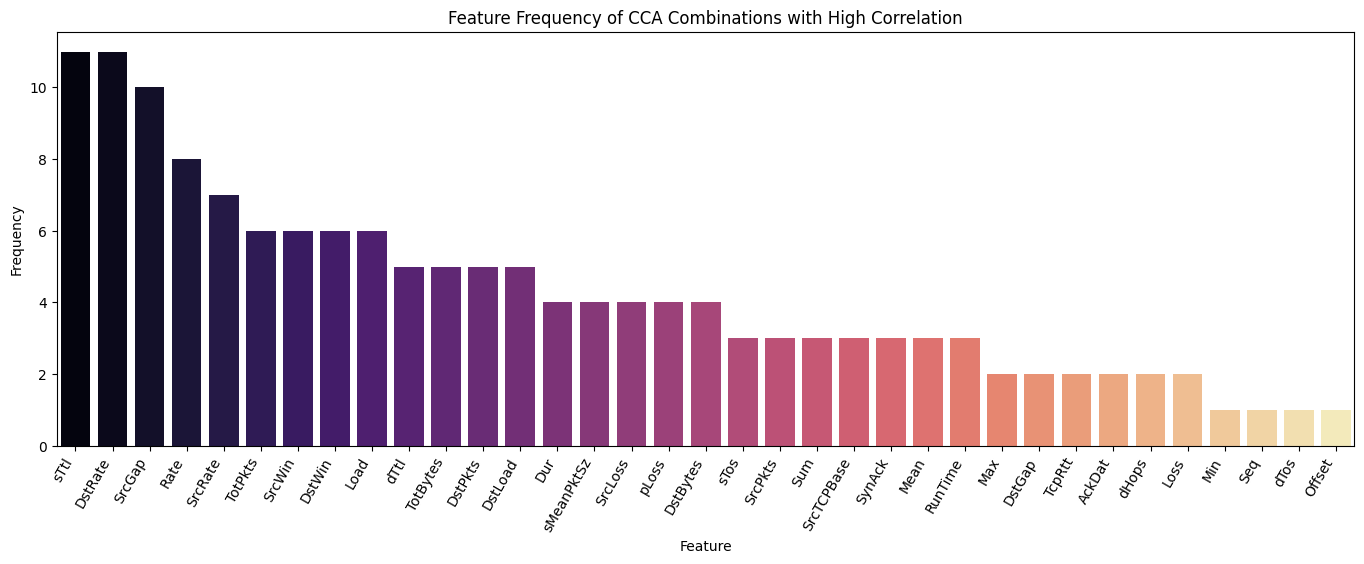

In [25]:
from collections import Counter

threshold = df_cca_sorted['Canonical_Correlation'].quantile(0.9)
df_filtered = df_cca_sorted[df_cca_sorted['Canonical_Correlation'] >= threshold]
all_features = []

for _, row in df_filtered.iterrows():
    all_features.extend(row['Feature_X'])
    all_features.extend(row['Feature_Y'])

feature_counts = Counter(all_features)

df_feature_freq = pd.DataFrame(feature_counts.items(), columns=['Feature', 'Frequency'])
df_feature_freq = df_feature_freq.sort_values(by='Frequency', ascending=False)


plt.figure(figsize=(14, 6))
sns.barplot(data=df_feature_freq, x='Feature', y='Frequency', palette='magma')

plt.title("Feature Frequency of CCA Combinations with High Correlation")
plt.xlabel("Feature")
plt.ylabel("Frequency")
plt.xticks(rotation=60, ha='right')
plt.tight_layout(pad=2.0)

plt.show()